## RUL Regression

In [24]:
# path setup
import sys
import os
project_root=os.path.abspath(os.path.join(os.getcwd(),'..'))
sys.path.append(project_root)

print(f"Project root: {project_root}")

Project root: c:\Users\aryap\Desktop\predictive_maintenance


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.preprocessing import StandardScaler
import joblib

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries imported")

Libraries imported


Load engineered data

In [26]:
#load from csv 
data_path=os.path.join(project_root,'data','engineered_data.csv')
df=pd.read_csv(data_path)
print("Data loaded")
print(f" Shape: {df.shape}")
print(f" Columns: {df.columns.tolist()}")

Data loaded
 Shape: (10000, 13)
 Columns: ['air_temperature', 'process_temperature', 'rotational_speed', 'torque', 'tool_wear', 'temp_diff', 'power', 'tool_wear_torque', 'type_encoded', 'rul', 'failure_mode_encoded', 'failure_mode', 'machine_failure']


Defining feature set and targets

In [27]:
feature_columns=[
    'air_temperature',
    'process_temperature',
    'rotational_speed',
    'torque',
    'tool_wear',
    'temp_diff',
    'power',
    'tool_wear_torque',
    'type_encoded'
]

rul_target='rul'

X=df[feature_columns]
y=df[rul_target]

print("Features and target defined")
print(f"   X shape : {X.shape}")
print(f"   y shape : {y.shape}")
print(f"\n   Target (RUL) stats:")
print(f"   Min    : {y.min()}")
print(f"   Max    : {y.max()}")
print(f"   Mean   : {y.mean():.2f}")
print(f"   Std    : {y.std():.2f}")

Features and target defined
   X shape : (10000, 9)
   y shape : (10000,)

   Target (RUL) stats:
   Min    : 0
   Max    : 240
   Mean   : 128.79
   Std    : 66.40


Train test split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

print("Train test split done")
print(f" Train size: {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f" Test size: {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.0f}%)")

Train test split done
 Train size: 8000 rows (80%)
 Test size: 2000 rows (20%)


**Linear Regression Baseline**

Train Linear Regression

In [29]:
# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#train
lr_model=LinearRegression()
lr_model.fit(X_train_scaled,y_train)

# predict
y_pred_lr=lr_model.predict(X_test_scaled)

#clip predictions - RUL cannot be negative or above 240
y_pred_lr=np.clip(y_pred_lr,0,240)

print("Linear Regression model trained and predictions made")
print(f"Prediction range : {y_pred_lr.min():.2f} to {y_pred_lr.max():.2f}")

Linear Regression model trained and predictions made
Prediction range : 0.00 to 240.00


Evaluation linear regression

In [30]:
# evaluation metrics
lr_rmse=np.sqrt(mean_squared_error(y_test,y_pred_lr))
lr_mae=mean_absolute_error(y_test,y_pred_lr)
lr_r2=r2_score(y_test,y_pred_lr)

print("Linear Regression- Performance Metrics")

print(f"RMSE : {lr_rmse:.4f} minutes")
print(f"MAE : {lr_mae:.4f} minutes")
print(f"R² : {lr_r2:.4f}")


print(f"""
Interpretation:
→ RMSE of {lr_rmse:.1f} means predictions are off by
  ~{lr_rmse:.1f} minutes on average (penalises large errors)
→ MAE  of {lr_mae:.1f} means typical prediction error
  is ~{lr_mae:.1f} minutes
→ R²   of {lr_r2:.3f} means the model explains
  {lr_r2*100:.1f}% of variance in RUL
""")


Linear Regression- Performance Metrics
RMSE : 18.8830 minutes
MAE : 7.5210 minutes
R² : 0.9224

Interpretation:
→ RMSE of 18.9 means predictions are off by
  ~18.9 minutes on average (penalises large errors)
→ MAE  of 7.5 means typical prediction error
  is ~7.5 minutes
→ R²   of 0.922 means the model explains
  92.2% of variance in RUL



Cross Validation

In [31]:
# cross validation gives more reliable performance estimates than a single train test split
cv_scores=cross_val_score(
    LinearRegression(),
    scaler.fit_transform(X),
    y,
    cv=5,
    scoring='r2'
)

print("Linear Regression - 5 fold cross validation")

for i,score in enumerate(cv_scores,1):
    print(f" Fold {i} R² : {score:.4f}")

print(f"Mean R² : {cv_scores.mean():.4f}")
print(f"Std R² : {cv_scores.std():.4f}")

Linear Regression - 5 fold cross validation
 Fold 1 R² : 0.9434
 Fold 2 R² : 0.9313
 Fold 3 R² : 0.7514
 Fold 4 R² : 0.9413
 Fold 5 R² : 0.9643
Mean R² : 0.9063
Std R² : 0.0782


Visualize Linear Regression results

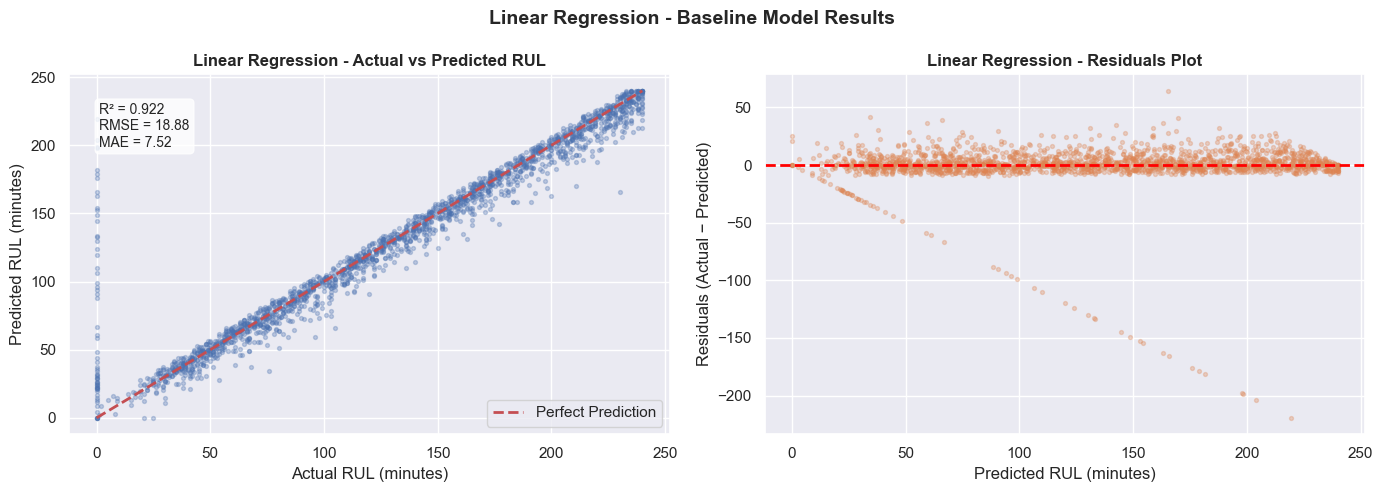

In [34]:
fig,axes=plt.subplots(1,2,figsize=(14,5))

#actual vs predicted
axes[0].scatter(
    y_test,y_pred_lr,
    alpha=0.3,
    s=8,
    color = '#4C72B0'
)

# perfect predictions line
min_val = min(y_test.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred_lr.max())
axes[0].plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--', linewidth=2, label='Perfect Prediction'
)


axes[0].set_title('Linear Regression - Actual vs Predicted RUL',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual RUL (minutes)')
axes[0].set_ylabel('Predicted RUL (minutes)')
axes[0].legend()
axes[0].text(
    0.05, 0.92,
    f'R² = {lr_r2:.3f}\nRMSE = {lr_rmse:.2f}\nMAE = {lr_mae:.2f}',
    transform  = axes[0].transAxes,
    fontsize   = 10,
    verticalalignment = 'top',
    bbox       = dict(boxstyle='round', facecolor='white', alpha=0.8)
)

#residuals plot
residuals = y_test - y_pred_lr

axes[1].scatter(
    y_pred_lr, residuals,
    alpha = 0.3,
    s     = 8,
    color = '#DD8452'
)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Linear Regression - Residuals Plot',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted RUL (minutes)')
axes[1].set_ylabel('Residuals (Actual − Predicted)')

plt.suptitle('Linear Regression - Baseline Model Results',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/lr_results.png', dpi=150, bbox_inches='tight')
plt.show()

Feature coefficients

In [35]:
#see which features Linear Regression weighted most
coefficients=pd.DataFrame({
    'Feature':feature_columns,
    'Coefficient':lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Linear Regression - Feature Coefficients")
print(f"{'Feature':<25} {'Coefficient':>12}")
for _, row in coefficients.iterrows():
    direction = "positive" if row['Coefficient'] > 0 else "negative"
    print(f"{row['Feature']:<25} {row['Coefficient']:>10.4f} ({direction})")

print("\n Positive coefficients mean higher value = higher RUL")
print(" Negative coefficients mean higher value = lower RUL")

Linear Regression - Feature Coefficients
Feature                    Coefficient
tool_wear                   -66.3950 (negative)
torque                      -48.9151 (negative)
power                        28.4614 (positive)
rotational_speed            -18.1648 (negative)
tool_wear_torque              4.6667 (positive)
temp_diff                     2.2143 (positive)
air_temperature              -0.8372 (negative)
process_temperature           0.3574 (positive)
type_encoded                  0.2475 (positive)

 Positive coefficients mean higher value = higher RUL
 Negative coefficients mean higher value = lower RUL


## Random Forest Regressor

Train Random Forest with default params

In [36]:
rf_model=RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1 # use all CPU cores for faster training
)

rf_model.fit(X_train,y_train)

y_pred_rf=rf_model.predict(X_test)
y_pred_rf=np.clip(y_pred_rf,0,240)

print("Random Forest trained and predictions made")
print(f"Prediction range : {y_pred_rf.min():.2f} to {y_pred_rf.max():.2f}")


Random Forest trained and predictions made
Prediction range : 0.00 to 240.00


Evaluate Random Forest

In [37]:
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_r2   = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor - Performance Metrics")
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE: {rf_mae:.4f}")
print(f"R²: {rf_r2:.4f}")

print(f"""
Interpretation:
→ RMSE of {rf_rmse:.1f} means predictions are off by
  ~{rf_rmse:.1f} minutes on average
→ MAE  of {rf_mae:.1f} means typical prediction error
  is ~{rf_mae:.1f} minutes
→ R²   of {rf_r2:.3f} means the model explains
  {rf_r2*100:.1f}% of variance in RUL
""")

Random Forest Regressor - Performance Metrics
RMSE: 9.1110
MAE: 1.7314
R²: 0.9819

Interpretation:
→ RMSE of 9.1 means predictions are off by
  ~9.1 minutes on average
→ MAE  of 1.7 means typical prediction error
  is ~1.7 minutes
→ R²   of 0.982 means the model explains
  98.2% of variance in RUL



Visualize Random Forest results

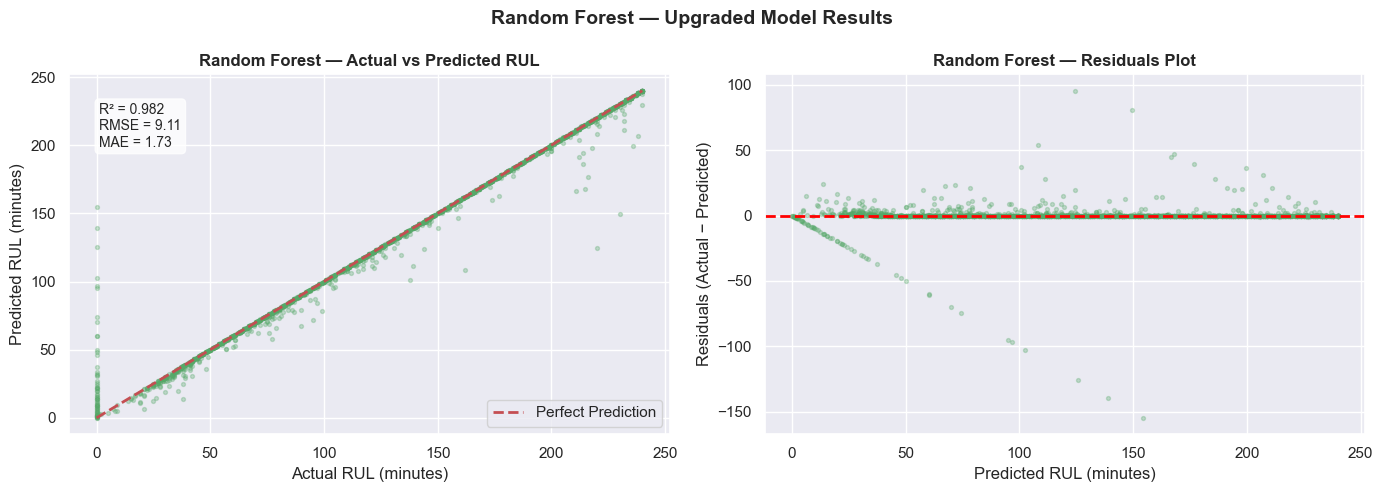

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Actual vs Predicted ──
axes[0].scatter(
    y_test, y_pred_rf,
    alpha = 0.3,
    s     = 8,
    color = '#55A868'
)

min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
axes[0].plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--', linewidth=2, label='Perfect Prediction'
)

axes[0].set_title('Random Forest — Actual vs Predicted RUL',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual RUL (minutes)')
axes[0].set_ylabel('Predicted RUL (minutes)')
axes[0].legend()
axes[0].text(
    0.05, 0.92,
    f'R² = {rf_r2:.3f}\nRMSE = {rf_rmse:.2f}\nMAE = {rf_mae:.2f}',
    transform  = axes[0].transAxes,
    fontsize   = 10,
    verticalalignment = 'top',
    bbox       = dict(boxstyle='round', facecolor='white', alpha=0.8)
)

# ── Right: Residuals plot ──
residuals_rf = y_test - y_pred_rf

axes[1].scatter(
    y_pred_rf, residuals_rf,
    alpha = 0.3,
    s     = 8,
    color = '#55A868'
)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Random Forest — Residuals Plot',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted RUL (minutes)')
axes[1].set_ylabel('Residuals (Actual − Predicted)')

plt.suptitle('Random Forest — Upgraded Model Results',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/rf_regressor_results.png', dpi=150, bbox_inches='tight')
plt.show()


Feature Importance

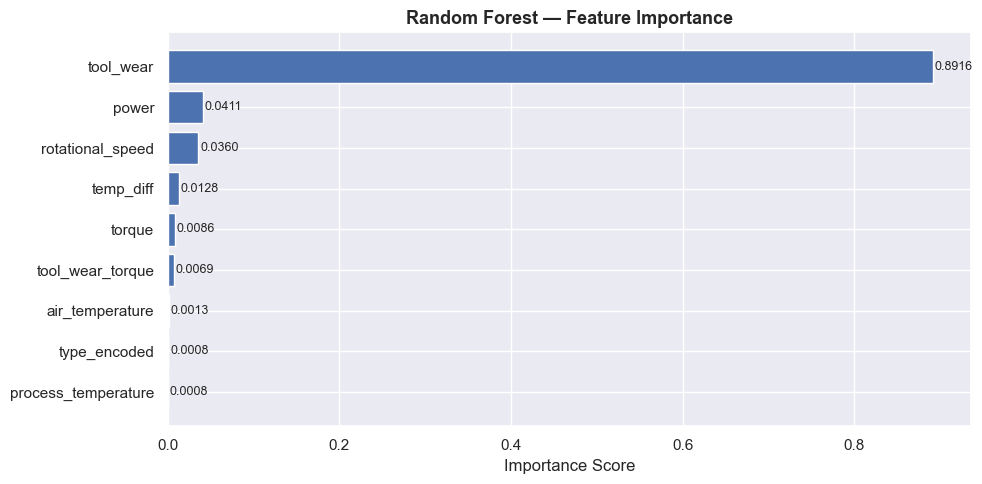


 Feature Importance Ranking: 
  tool_wear              0.8916  89
  power                  0.0411  4
  rotational_speed       0.0360  3
  temp_diff              0.0128  1
  torque                 0.0086  0
  tool_wear_torque       0.0069  0
  air_temperature        0.0013  0
  type_encoded           0.0008  0
  process_temperature    0.0008  0


In [41]:
importances=pd.DataFrame({
    'Feature' : feature_columns,
    'Importance' : rf_model.feature_importances_
}).sort_values('Importance',ascending=False)

fig,ax=plt.subplots(figsize=(10,5))

bars = ax.barh(
    importances['Feature'],
    importances['Importance'],
    color     = '#4C72B0',
    edgecolor = 'white'
)

for bar,val in zip(bars,importances['Importance']):
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center', fontsize=9
    )

ax.set_title('Random Forest — Feature Importance',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../notebooks/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Feature Importance Ranking: ")

for _, row in importances.iterrows():
    bar_fill=int(row['Importance'] * 100)
    print(f"  {row['Feature']:<22} {row['Importance']:.4f}  {bar_fill}")

Side by Side model comparison

 Model comparison- Linear Regression vs Random Forest
Metric        Linear Regression      Random Forest   Improvement
RMSE                    18.8830             9.1110        +51.8%
MAE                      7.5210             1.7314        +77.0%
R²                       0.9224             0.9819         +6.5%


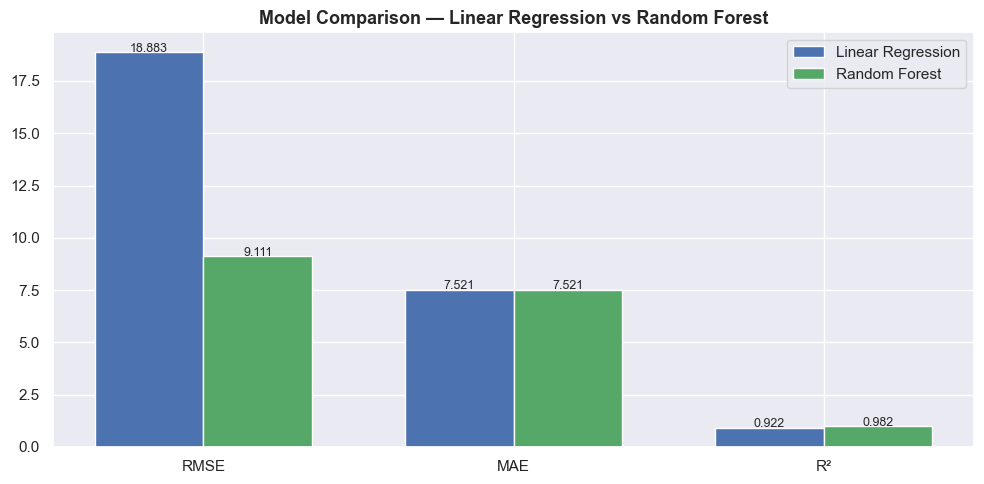

In [42]:
print(" Model comparison- Linear Regression vs Random Forest")
print(f"{'Metric' :<10} {'Linear Regression':>20} {'Random Forest':>18} {'Improvement':>13}")

rmse_imp=((lr_rmse - rf_rmse)/lr_rmse * 100)
mae_imp=((lr_mae  - rf_mae)  / lr_mae  * 100)
r2_imp=((rf_r2 - lr_r2) / lr_r2 * 100)

print(f"{'RMSE':<10} {lr_rmse:>20.4f} {rf_rmse:>18.4f} {rmse_imp:>+12.1f}%")
print(f"{'MAE':<10} {lr_mae:>20.4f} {rf_mae:>18.4f} {mae_imp:>+12.1f}%")
print(f"{'R²':<10} {lr_r2:>20.4f} {rf_r2:>18.4f} {r2_imp:>+12.1f}%")

fig,ax=plt.subplots(figsize=(10,5))

metrics=['RMSE','MAE','R²']
lr_values=[lr_rmse,lr_mae,lr_r2]
rf_values=[rf_rmse,lr_mae,rf_r2]

x=np.arange(len(metrics))
width=0.35

bars1=ax.bar(x-width/2,lr_values,width,
label='Linear Regression',color='#4C72B0',edgecolor='white')
bars2=ax.bar(x+width/2,rf_values,width,
label='Random Forest',color='#55A868',edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

ax.set_title('Model Comparison — Linear Regression vs Random Forest',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Save the Random Forest model

In [43]:
model_path=os.path.join(project_root,'models','rf_regressor.pkl')

joblib.dump(rf_model,model_path)

print(f"Random Forest Regressor saved ")
print(f"Path : {model_path}")
print(f"Size : {os.path.getsize(model_path)/1024:.1f} KB")

#save scaler 
scaler_path=os.path.join(project_root, 'models', 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"   Path : {scaler_path}")

Random Forest Regressor saved 
Path : c:\Users\aryap\Desktop\predictive_maintenance\models\rf_regressor.pkl
Size : 7131.3 KB
   Path : c:\Users\aryap\Desktop\predictive_maintenance\models\scaler.pkl
